# <center>Category 3: Prescriptive Analysis</center>

### 1. Gender vs Time in Hyperglycemia - Do male and female patients spend different amounts of time in hyperglycemia (glucose > 180)?

##### **Reason:** This question helps identify whether male and female patients spend different amounts of time in a hyperglycemic state (glucose > 180 mg/dL). Research suggests that hormonal differences between males and females can influence insulin sensitivity and glucose regulation. In female T1DM patients, fluctuations in estrogen and progesterone levels may contribute to greater variability in blood glucose levels. Comparing hyperglycemia duration between genders in this dataset can help determine whether similar patterns are observed here.

*** Hyperglycemia % per Patient with Gender ***
   patient_id  total_readings  hyper_readings  hyper_percentage  gender
0   HUPA0001P            4096            1723             42.07    Male
1   HUPA0002P            3181             466             14.65    Male
2   HUPA0003P            3770             954             25.31    Male
3   HUPA0004P            3184            1448             45.48  Female
4   HUPA0005P            3858             973             25.22    Male
5   HUPA0006P            2290             809             35.33    Male
6   HUPA0007P            3857            1743             45.19    Male
7   HUPA0009P            3812            2232             58.55  Female
8   HUPA0010P            2976             501             16.83    Male
9   HUPA0011P            3839            1238             32.25  Female
10  HUPA0014P            3829            1987             51.89    Male
11  HUPA0015P            3792            1409             37.16  Female
12  HUPA0016P   

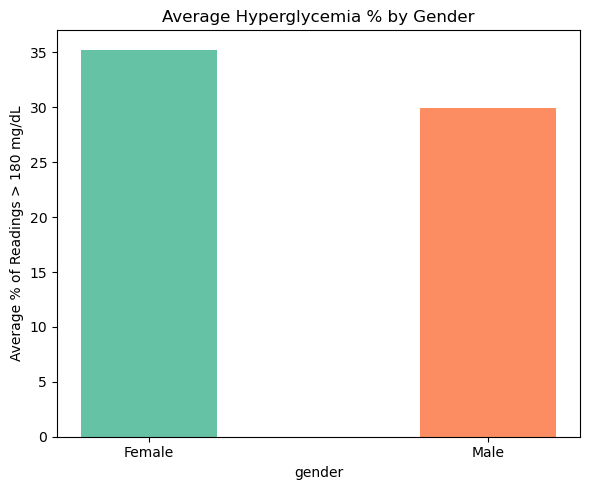

In [10]:
#Importing all the Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore", UserWarning)

# Reading file
df_all = pd.read_excel("Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx")

# Calculating hyperglycemia readings per patient
total_readings   = df_all.groupby('patient_id')['glucose'].count()
hyper_readings   = df_all[df_all['glucose'] > 180].groupby('patient_id')['glucose'].count()

# Dataframe summary per patient with gender
hyper_summary = pd.DataFrame({
    'total_readings' : total_readings,
    'hyper_readings' : hyper_readings,
    'hyper_percentage': ((hyper_readings / total_readings) * 100).round(2)}).fillna(0).reset_index()

# Adding gender column to the dataframe and merging using left join
patient_gender = df_all[['patient_id', 'gender']].drop_duplicates()
hyper_summary  = hyper_summary.merge(patient_gender, on='patient_id', how='left')

print("*** Hyperglycemia % per Patient with Gender ***")
print(hyper_summary)

# Finding average hyperglycemia % by gender
gender_summary = hyper_summary.groupby('gender')['hyper_percentage'].agg(
    Mean_Hyper_Pct = 'mean',
    Patient_Count  = 'count'
).round(2)

print("\n*** Average % in Hyperglycemia by Gender ***")
print(gender_summary)

# Visualization
# Bar Chart 1 - Average hyperglycemia % by gender
x1 = gender_summary.index
y1 = gender_summary['Mean_Hyper_Pct']

plt.figure(figsize=(6, 5))
plt.bar(x1, y1, width=0.4, color=plt.cm.Set2(range(len(x1))))
plt.title('Average Hyperglycemia % by Gender')
plt.xlabel('gender')
plt.ylabel('Average % of Readings > 180 mg/dL')
plt.tight_layout()
plt.show()

**<span style="color:green">Key Insights: The average hyperglycemia in female patients is 35.25% when compared to male patients which is, 29.96%. In T1DM, hormonal fluctuations in female patients (estrogen and progesterone) are known to affect insulin sensitivity, which can cause unpredictable glucose swings. As seen in the above insights a higher hyperglycemia % in females may reflect these hormonal effects on glucose regulation.  </green>**

### 2. Basal Rate vs Overnight Glucose Stability - Do patients with higher overnight basal rates have more stable glucose between 12AM–6AM?

##### **Reason:** This question is important because the primary purpose of basal insulin is to maintain stable glucose levels during fasting periods and sleep. If glucose levels fluctuate significantly overnight despite a programmed basal rate, it may indicate that the insulin delivery settings are not properly calibrated for the patient’s physiological needs. Ideally, comparing basal rate levels to overnight glucose variance should directly test whether the pump settings are working as intended.

In [11]:
# Reading file
df = pd.read_excel("Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx")

# Filtering overnight readings (12AM - 6AM)
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.time
overnight  = df[df['time'].apply(lambda x: x >= pd.Timestamp('00:00').time() and x <= pd.Timestamp('06:00').time())]

print(f"Total overnight readings : {len(overnight)}")

# Calculating glucose stability (standard deviation) per patient overnight
overnight_stability = overnight.groupby('patient_id').agg(
    avg_glucose     = ('glucose',    'mean'),
    std_glucose     = ('glucose',    'std'),
    avg_basal_rate  = ('basal_rate', 'mean')
).round(2).reset_index()

# Sorting by average standard deviation glucose descending
overnight_stability = overnight_stability.sort_values(
    by='std_glucose',
    ascending=False
)

print("\n*** Overnight Glucose Stability per Patient ***")
print(overnight_stability)

Total overnight readings : 78173

*** Overnight Glucose Stability per Patient ***
   patient_id  avg_glucose  std_glucose  avg_basal_rate
5   HUPA0006P       153.10        96.78            0.08
12  HUPA0016P       165.11        89.90            0.09
16  HUPA0020P       217.86        84.06            0.08
2   HUPA0003P       150.45        81.78            0.06
10  HUPA0014P       212.99        79.90            0.00
6   HUPA0007P       144.08        78.54            0.09
20  HUPA0024P       157.35        76.07            0.04
0   HUPA0001P       173.11        76.05            0.05
3   HUPA0004P       141.91        69.19            0.08
15  HUPA0019P       171.45        68.02            0.06
14  HUPA0018P       175.90        67.73            0.00
22  HUPA0026P       159.14        67.18            0.04
13  HUPA0017P       223.92        59.21            0.06
1   HUPA0002P       104.22        56.67            0.08
11  HUPA0015P       156.60        53.56            0.00
8   HUPA0010P       11

**<span style="color:green">Key Insights: The overnight glucose analysis revealed substantial variability in glucose stability across patients. Patients such as HUPA0006P, HUPA0016P, and HUPA0020P exhibited high glucose standard deviations, indicating unstable overnight glycemic control. However, higher glucose variability did not consistently correspond to lower or higher basal insulin rates. For example, patients HUPA0022P and HUPA0025P maintained comparatively lower glucose variability despite receiving relatively higher basal rates. These findings suggest that overnight glucose stability may be influenced by multiple factors beyond basal insulin dosing alone, including insulin sensitivity, meal timing, lifestyle behaviors, and correction bolus administration.</green>**

### 3. Does Carb Intake Cause a Glucose Spike in the Next Interval?

##### Why these variables are related
Carbohydrates are broken down into glucose and absorbed into the bloodstream 
within 15–30 minutes. In T1DM patients without adequate bolus coverage, this 
causes a measurable spike. The 5-minute interval data lets us observe this 
effect almost in real time.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("/Users/vyshnaviandhavarapu/Desktop/TIM_CLASSES/Python Hackathon/Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx")
print(df.shape)
print(df.columns.tolist())

(309392, 16)
['glucose', 'calories', 'heart_rate', 'steps', 'basal_rate', 'bolus_volume_delivered', 'carb_input', 'patient_id', 'date', 'time', 'age', 'gender', 'race', 'average_sleep_duration_(hrs)', 'sleep_quality_(1-10)', '%_with_sleep_disturbances']


Correlation between carb input and glucose rise:
              carb_input  glucose_rise
carb_input      1.000000     -0.198452
glucose_rise   -0.198452      1.000000
Mean glucose rise after carb event: 1.14 mg/dL


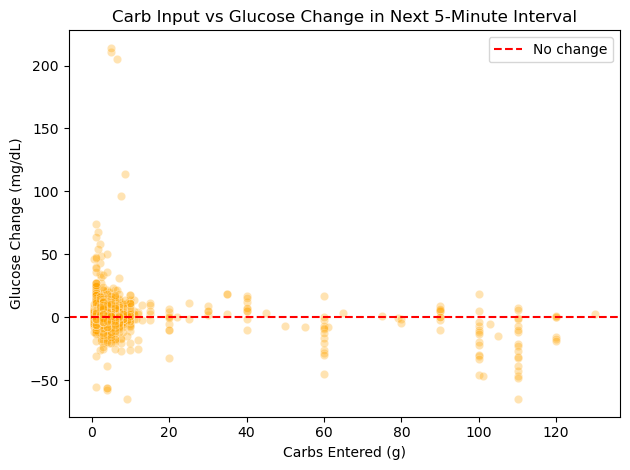

In [13]:
df_sorted = df.sort_values(['patient_id', 'date', 'time']).copy()
df_sorted['next_glucose'] = df_sorted.groupby('patient_id')['glucose'].shift(-1)
df_sorted['glucose_rise'] = df_sorted['next_glucose'] - df_sorted['glucose']

meals = df_sorted[df_sorted['carb_input'] > 0].dropna(subset=['glucose_rise'])

print("Correlation between carb input and glucose rise:")
print(meals[['carb_input', 'glucose_rise']].corr())
print(f"Mean glucose rise after carb event: {meals['glucose_rise'].mean():.2f} mg/dL")

sns.scatterplot(data=meals, x='carb_input', y='glucose_rise', alpha=0.3, color='orange')
plt.axhline(0, color='red', linestyle='--', label='No change')
plt.title("Carb Input vs Glucose Change in Next 5-Minute Interval")
plt.xlabel("Carbs Entered (g)")
plt.ylabel("Glucose Change (mg/dL)")
plt.legend()
plt.tight_layout()
plt.show()

##### Finding
The correlation between carb intake and glucose rise in the next 5-minute 
interval is -0.20, which is weak and slightly negative. This is clinically 
explainable — patients often enter carb data at the same time as giving a 
bolus dose, meaning the insulin counteracts the expected glucose rise within 
the same interval. The mean glucose change after a carb event was only 
+1.14 mg/dL, suggesting bolus insulin is partially offsetting the immediate 
spike. A longer lag time of 15–30 minutes would likely show a stronger 
positive relationship.

### 4. Does Physical Activity Reduce Glucose in the Following Interval?

##### Why these variables are related
Exercise causes muscles to absorb glucose independently of insulin, called 
non-insulin-mediated glucose uptake. For T1DM patients, physical activity is 
one of the most effective natural glucose-lowering mechanisms, but it also 
carries hypoglycemia risk if insulin doses are not adjusted accordingly.

Correlation between steps and glucose change:
                   steps  glucose_change
steps           1.000000       -0.099522
glucose_change -0.099522        1.000000
Mean glucose change during active intervals: -0.26 mg/dL


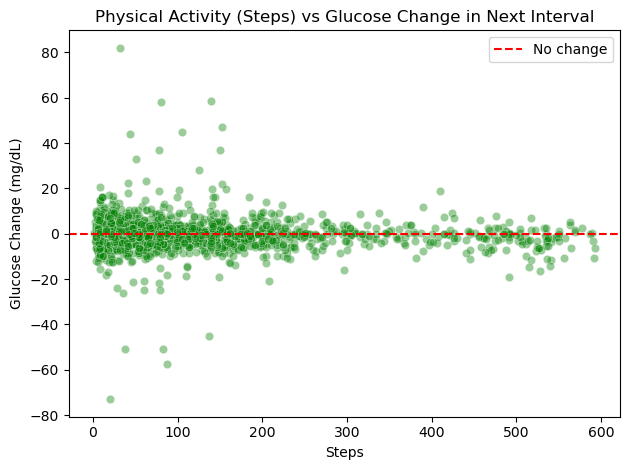

In [14]:
df_sorted['glucose_change'] = df_sorted['next_glucose'] - df_sorted['glucose']
active = df_sorted[df_sorted['steps'] > 0].dropna(subset=['glucose_change'])

print("Correlation between steps and glucose change:")
print(active[['steps', 'glucose_change']].corr())
print(f"Mean glucose change during active intervals: {active['glucose_change'].mean():.2f} mg/dL")

sns.scatterplot(data=active.sample(2000, random_state=42),
                x='steps', y='glucose_change', alpha=0.4, color='green')
plt.axhline(0, color='red', linestyle='--', label='No change')
plt.title("Physical Activity (Steps) vs Glucose Change in Next Interval")
plt.xlabel("Steps")
plt.ylabel("Glucose Change (mg/dL)")
plt.legend()
plt.tight_layout()
plt.show()

##### Finding
The correlation between steps and glucose change in the next interval is -0.10, 
indicating a weak negative relationship — more steps are associated with a 
slight glucose decrease. The mean glucose change during active intervals was 
-0.26 mg/dL, confirming a small but consistent glucose-lowering effect. While 
weak at the 5-minute level, this is expected — the glucose-lowering effect of 
exercise accumulates over longer periods. This still supports the clinical 
recommendation for T1DM patients to maintain physical activity as part of 
glucose management.

### 5. Do Patients With Poor Sleep Quality Have Higher Average Glucose?

##### Why these variables are related
Poor sleep elevates cortisol and growth hormone, both of which increase insulin 
resistance. In T1DM, this makes glucose harder to control even with the same 
insulin doses. Research shows even one night of poor sleep can raise next-day 
glucose significantly.

Correlation matrix:
                    avg_glucose  sleep_quality  sleep_disturbances
avg_glucose            1.000000       0.046668            0.279695
sleep_quality          0.046668       1.000000           -0.037980
sleep_disturbances     0.279695      -0.037980            1.000000


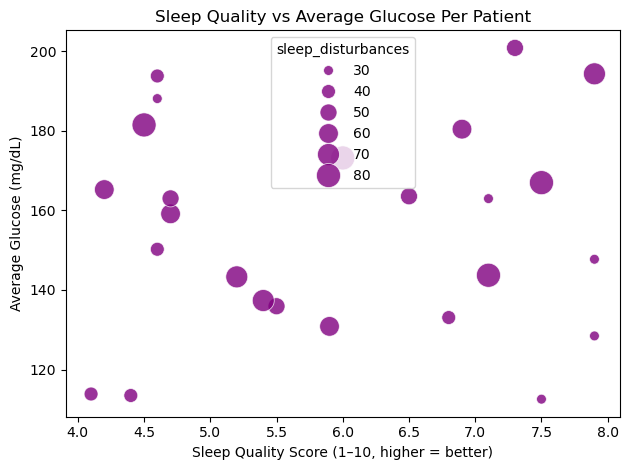

In [15]:
patient_summary = df.groupby('patient_id').agg(
    avg_glucose=('glucose', 'mean'),
    sleep_quality=('sleep_quality_(1-10)', 'first'),
    sleep_disturbances=('%_with_sleep_disturbances', 'first')
).reset_index()

print("Correlation matrix:")
print(patient_summary[['avg_glucose', 'sleep_quality', 'sleep_disturbances']].corr())

sns.scatterplot(data=patient_summary, x='sleep_quality', y='avg_glucose',
                size='sleep_disturbances', sizes=(50, 300),
                alpha=0.8, color='purple')
plt.title("Sleep Quality vs Average Glucose Per Patient")
plt.xlabel("Sleep Quality Score (1–10, higher = better)")
plt.ylabel("Average Glucose (mg/dL)")
plt.tight_layout()
plt.show()

##### Finding
The correlation between sleep quality and average glucose is only 0.05, 
suggesting no strong direct relationship. However sleep disturbance percentage 
shows a stronger correlation with average glucose at 0.28 — patients who 
experience more frequent sleep disruptions tend to have higher average glucose. 
HUPA0017P has the highest average glucose (200.80 mg/dL) and a high disturbance 
rate, while HUPA0022P has one of the lowest (112.55 mg/dL) despite a good sleep 
quality score of 7.5. This suggests sleep disturbances may be a more meaningful 
metric than sleep quality score alone for predicting glucose control in T1DM.

### 6. Does Bolus Insulin Effectively Reduce Glucose After a Meal?

##### Why these variables are related
Bolus insulin is specifically delivered to counteract post-meal glucose spikes 
in T1DM pump therapy. A correctly dosed bolus should bring glucose down within 
1–2 hours. This tests whether pump therapy is working as intended and whether 
higher bolus volumes produce proportionally greater glucose reduction.

Correlation between bolus volume and 2-hour glucose change:
                        bolus_volume_delivered  glucose_change_2hr
bolus_volume_delivered                1.000000            0.153089
glucose_change_2hr                    0.153089            1.000000
Mean glucose change 2hrs after bolus: -1.11 mg/dL


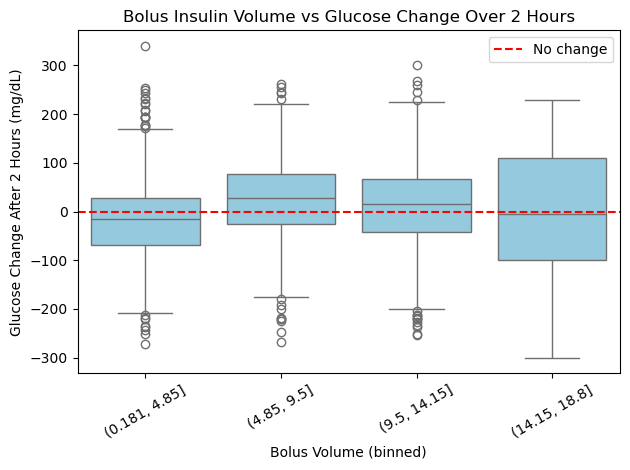

In [16]:
bolus_events = df_sorted[df_sorted['bolus_volume_delivered'] > 0].copy()
bolus_events['glucose_2hrs_later'] = bolus_events.groupby('patient_id')['glucose'].shift(-24)
bolus_events['glucose_change_2hr'] = bolus_events['glucose_2hrs_later'] - bolus_events['glucose']
bolus_events = bolus_events.dropna(subset=['glucose_change_2hr'])

print("Correlation between bolus volume and 2-hour glucose change:")
print(bolus_events[['bolus_volume_delivered', 'glucose_change_2hr']].corr())
print(f"Mean glucose change 2hrs after bolus: {bolus_events['glucose_change_2hr'].mean():.2f} mg/dL")

bolus_events['bolus_bin'] = pd.cut(bolus_events['bolus_volume_delivered'], bins=4)
sns.boxplot(data=bolus_events, x='bolus_bin', y='glucose_change_2hr', color='skyblue')
plt.axhline(0, color='red', linestyle='--', label='No change')
plt.title("Bolus Insulin Volume vs Glucose Change Over 2 Hours")
plt.xlabel("Bolus Volume (binned)")
plt.ylabel("Glucose Change After 2 Hours (mg/dL)")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

##### Finding
The correlation between bolus volume and glucose change over 2 hours is 0.15, 
weak but positive — larger bolus doses are associated with slightly more glucose 
reduction. The mean glucose change 2 hours after a bolus event was -1.11 mg/dL, 
confirming bolus delivery produces a net glucose decrease on average. The weak 
correlation may reflect variability in meal size, timing, and individual insulin 
sensitivity across the 25 patients. Overall bolus insulin therapy is working 
directionally as expected but dosing consistency across patients appears 
variable.

### 7. Are Older Patients Spending More Time in Hyperglycemia?

##### Why these variables are related
Older T1DM patients may have had the disease longer, leading to accumulated 
complications, reduced hypoglycemia awareness, and greater insulin resistance 
over time. Time above 180 mg/dL is the primary driver of long-term 
complications like retinopathy, nephropathy, and neuropathy.

Correlation between age and % time in hyperglycemia:
                        age  pct_hyperglycemic
age                1.000000           0.075278
pct_hyperglycemic  0.075278           1.000000


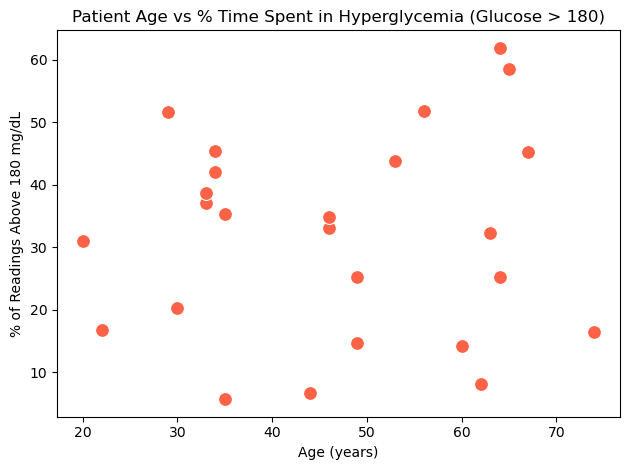

In [17]:
total_readings = df.groupby('patient_id').size()
hyper_readings = df[df['glucose'] > 180].groupby('patient_id').size()
pct_hyper = (hyper_readings / total_readings * 100).fillna(0).round(2)

patient_age = df.drop_duplicates('patient_id').set_index('patient_id')['age']

age_hyper = pd.DataFrame({
    'age': patient_age,
    'pct_hyperglycemic': pct_hyper
}).dropna()

print("Correlation between age and % time in hyperglycemia:")
print(age_hyper.corr())

sns.scatterplot(data=age_hyper, x='age', y='pct_hyperglycemic',
                color='tomato', s=100)
plt.title("Patient Age vs % Time Spent in Hyperglycemia (Glucose > 180)")
plt.xlabel("Age (years)")
plt.ylabel("% of Readings Above 180 mg/dL")
plt.tight_layout()
plt.show()

##### Finding
The correlation between age and percentage of time in hyperglycemia is 0.08, 
indicating almost no linear relationship. This contradicts the expected clinical 
pattern. However notable exceptions exist — HUPA0017P (age 64) spent 61.91% of 
readings above 180 mg/dL and HUPA0009P (age 65) spent 58.55%, both older 
patients with very high hyperglycemia rates. Meanwhile HUPA0020P (age 29) also 
had 51.68% hyperglycemia, showing younger patients can struggle equally. This 
suggests age alone is not a reliable predictor — disease duration, insulin 
regimen, and lifestyle factors likely play a larger role.